# Automatic Modulation Recognition - Baseline Implementation

**Students:** Lyes HADJAR, Moulay Mohamed BOUABDELLI  
**Course:** Wireless Communication Networks and Systems  
**Institution:** ENSIA - 4th Year, Semester 1 (2025/2026)

---

This notebook implements the baseline CNN architecture provided by the instructor for automatic modulation recognition across different SNR levels and equalization strategies.

## 1. Dataset Generation

Generate synthetic datasets with multiple modulation schemes (BPSK, 4-PAM, 8-PSK, 16-QAM, 2-FSK) transmitted through Rayleigh fading channel with AWGN noise.

In [1]:
import numpy as np
import os

# =========================================================
# PARAMETERS
# =========================================================

MODULATIONS = ['BPSK', '4-PAM', '8PSK', '16QAM', '2-FSK']
SNR_LIST = [-5, 0, 5, 10, 15, 20, 25]
NUM_SIGNALS = 1000
NUM_SAMPLES = 1024
BASE_DATASETS = {"raw": "dataset", "zf": "dataset_ZF", "mmse": "dataset_MMSE"}

In [2]:
# =========================================================
# SYMBOL GENERATION
# =========================================================
def generate_symbols(mod):
    if mod == 'BPSK':
        return np.random.choice([-1, 1], NUM_SAMPLES)
    if mod == '4-PAM':
        return np.random.choice([-3, -1, 1, 3], NUM_SAMPLES) / np.sqrt(5)
    if mod == '8PSK':
        return np.exp(1j * 2 * np.pi *
                     np.random.randint(0, 8, NUM_SAMPLES) / 8)
    if mod == '16QAM':
        a = np.random.choice([-3, -1, 1, 3], NUM_SAMPLES)
        b = np.random.choice([-3, -1, 1, 3], NUM_SAMPLES)
        return (a + 1j * b) / np.sqrt(10)
    if mod == '2-FSK':
        m = np.random.choice([0, 1], NUM_SAMPLES)
        return np.exp(1j * np.pi * (2 * m - 1) / 4)

In [3]:
# =========================================================
# CHANNEL & NOISE
# =========================================================
def rayleigh_channel(N):
    return (np.random.randn(N) +
            1j * np.random.randn(N)) / np.sqrt(2)

def add_awgn(x, snr_db):
    snr = 10**(snr_db / 10)
    power = np.mean(np.abs(x)**2)
    noise_var = power / snr
    noise = np.sqrt(noise_var / 2) * (
        np.random.randn(*x.shape) +
        1j * np.random.randn(*x.shape)
    )
    return x + noise, noise_var

In [4]:
# =========================================================
# EQUALIZATION
# =========================================================
def equalize(y, h, noise_var=None):
    zf = y / (h + 1e-9)
    if noise_var is None:
        return zf
    mmse = np.conj(h) * y / (np.abs(h)**2 + noise_var)
    return zf, mmse

In [5]:
# =========================================================
# COMPLETE DATASET GENERATION
# =========================================================
def generate_datasets():
    for snr in SNR_LIST:
        print(f"\nSNR = {snr} dB")
        
        # Storage for the three signal versions
        data = {"raw": [], "zf": [], "mmse": []}
        labels = []
        
        for label, mod in enumerate(MODULATIONS):
            print(f"  {mod}")
            for _ in range(NUM_SIGNALS):
                s = generate_symbols(mod)
                h = rayleigh_channel(NUM_SAMPLES)
                r = h * s
                r_noisy, noise_var = add_awgn(r, snr)
                
                # IQ format (2, 1024)
                iq_raw = np.stack([r_noisy.real, r_noisy.imag])
                zf_eq, mmse_eq = equalize(r_noisy, h, noise_var)
                iq_zf = np.stack([zf_eq.real, zf_eq.imag])
                iq_mmse = np.stack([mmse_eq.real, mmse_eq.imag])
                
                data["raw"].append(iq_raw)
                data["zf"].append(iq_zf)
                data["mmse"].append(iq_mmse)
                labels.append(label)
        
        # Conversion to NumPy arrays and saving
        labels = np.array(labels)
        for key in data:
            X = np.array(data[key])  # shape: (N_signals_total, 2, 1024)
            path = f"{BASE_DATASETS[key]}/SNR_{snr}"
            os.makedirs(path, exist_ok=True)
            np.save(f"{path}/X.npy", X)
            np.save(f"{path}/y.npy", labels)
        
        print(f"  Datasets saved for SNR {snr} dB")

if __name__ == "__main__":
    generate_datasets()
    print("\nGeneration of the three datasets completed.")


SNR = -5 dB
  BPSK
  4-PAM
  8PSK
  16QAM
  2-FSK
  Datasets saved for SNR -5 dB

SNR = 0 dB
  BPSK
  4-PAM
  8PSK
  16QAM
  2-FSK
  Datasets saved for SNR 0 dB

SNR = 5 dB
  BPSK
  4-PAM
  8PSK
  16QAM
  2-FSK
  Datasets saved for SNR 5 dB

SNR = 10 dB
  BPSK
  4-PAM
  8PSK
  16QAM
  2-FSK
  Datasets saved for SNR 10 dB

SNR = 15 dB
  BPSK
  4-PAM
  8PSK
  16QAM
  2-FSK
  Datasets saved for SNR 15 dB

SNR = 20 dB
  BPSK
  4-PAM
  8PSK
  16QAM
  2-FSK
  Datasets saved for SNR 20 dB

SNR = 25 dB
  BPSK
  4-PAM
  8PSK
  16QAM
  2-FSK
  Datasets saved for SNR 25 dB

Generation of the three datasets completed.


**Note:** Run the cell above to generate all datasets. This may take several minutes depending on your hardware.

## 2. Baseline CNN Model

Implementation of the baseline convolutional neural network for modulation classification.

In [6]:
# %% Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

2026-02-01 18:36:26.892276: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
# =========================================================
# PARAMETERS
# =========================================================
NUM_CLASSES = 5
MOD_LABELS = ['BPSK', '4-PAM', '8PSK', '16QAM', '2-FSK']
DATASETS = {"Raw": "dataset", "ZF": "dataset_ZF", "MMSE": "dataset_MMSE"}
SNR_LIST = [-5, 0, 5, 10, 15, 20, 25]

In [8]:
# =========================================================
# DATA LOADING FUNCTION
# =========================================================
def load_data(base_path, snr):
    X = np.load(f"{base_path}/SNR_{snr}/X.npy")  # (N, 2, 1024)
    y = np.load(f"{base_path}/SNR_{snr}/y.npy")
    X = np.transpose(X, (0, 2, 1))  # (N, 1024, 2)
    # Per-sample normalization (amplitude robustness)
    X = X / (np.max(np.abs(X), axis=(1, 2), keepdims=True) + 1e-8)
    return X, y

In [9]:
# =========================================================
# BASELINE CNN MODEL DEFINITION
# =========================================================
def build_cnn():
    model = Sequential([
        Input(shape=(1024, 2)),
        Conv1D(64, 7, activation='relu'),
        MaxPooling1D(2),
        Conv1D(128, 5, activation='relu'),
        MaxPooling1D(2),
        Conv1D(256, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [10]:
# =========================================================
# DISPLAY MODEL SUMMARY (ONCE)
# =========================================================
print("\n===================================")
print(" BASELINE CNN MODEL ARCHITECTURE ")
print("===================================")

baseline_model = build_cnn()
baseline_model.summary()


 BASELINE CNN MODEL ARCHITECTURE 


2026-02-01 18:36:36.591712: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1018, 64)       │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 509, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 505, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 252, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 125, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,192,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,334,149 (31.79 MB)

 Trainable params: 8,334,149 (31.79 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training and Evaluation

Train the baseline model on all three dataset versions (Raw, ZF, MMSE) across all SNR levels.


=== Dataset: Raw ===
  SNR = -5 dB → Accuracy: 20.00%


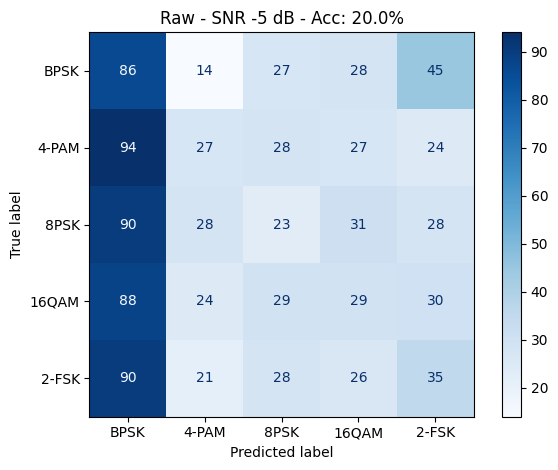

  SNR = 0 dB → Accuracy: 30.00%


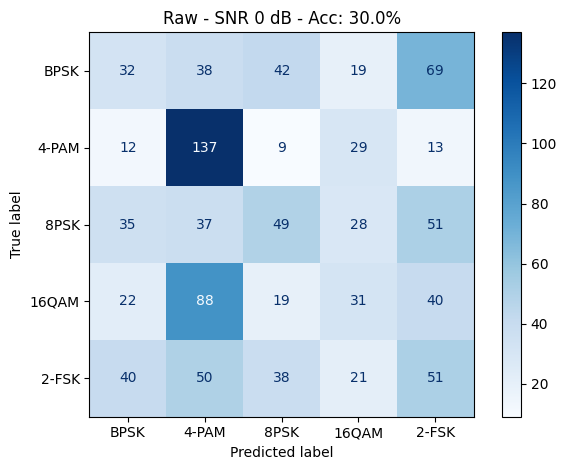

  SNR = 5 dB → Accuracy: 47.70%


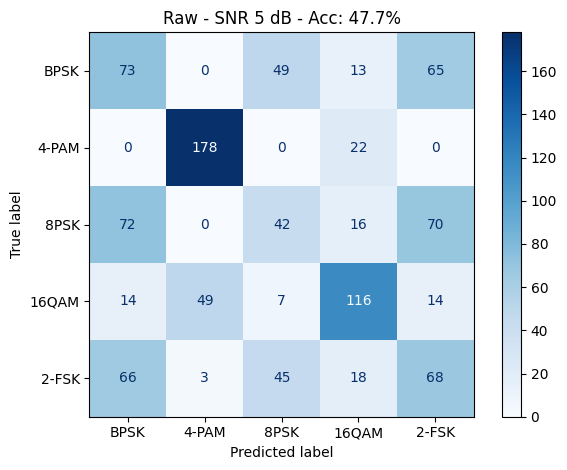

  SNR = 10 dB → Accuracy: 55.00%


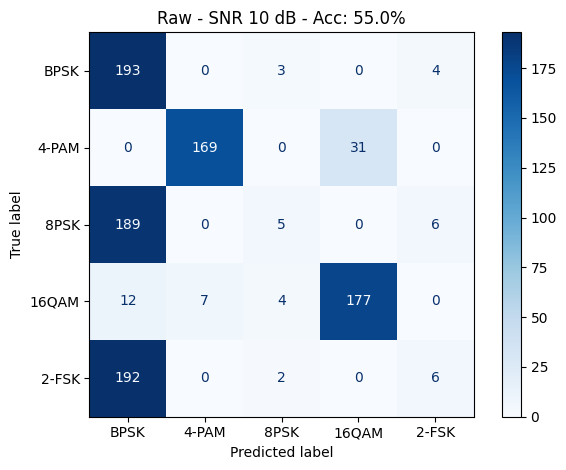

  SNR = 15 dB → Accuracy: 55.90%


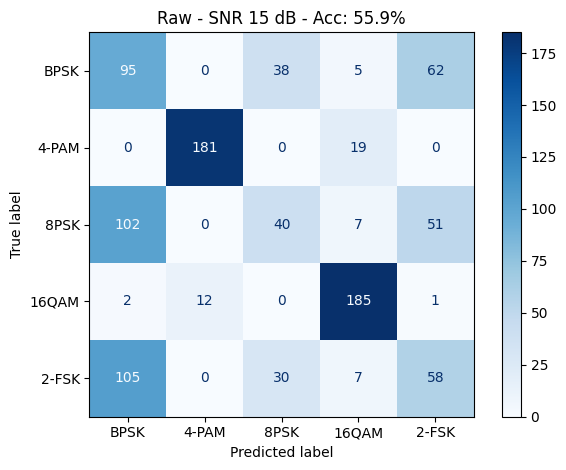

  SNR = 20 dB → Accuracy: 58.90%


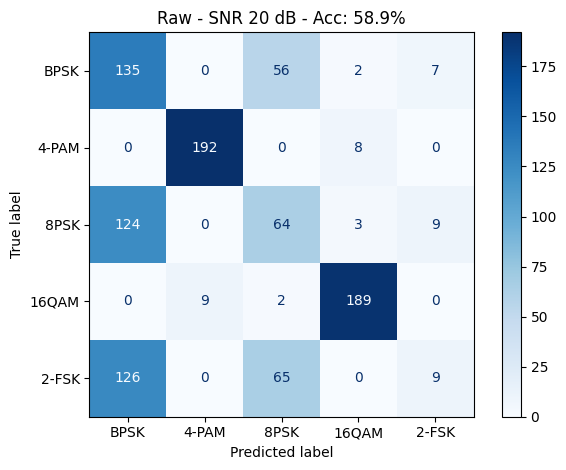

  SNR = 25 dB → Accuracy: 57.80%


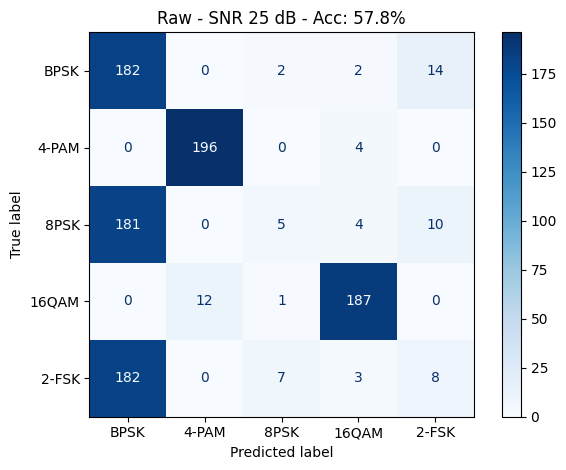


=== Dataset: ZF ===
  SNR = -5 dB → Accuracy: 39.80%


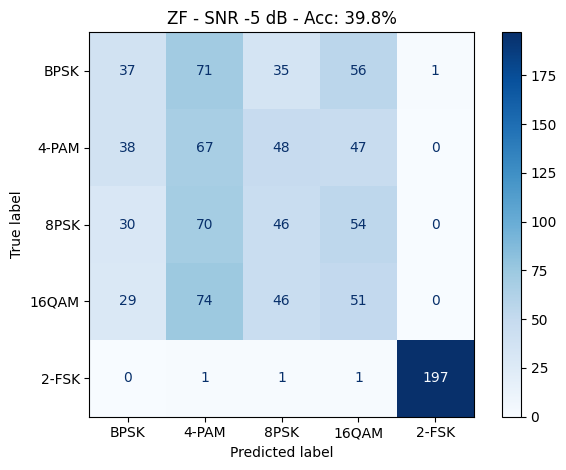

  SNR = 0 dB → Accuracy: 50.80%


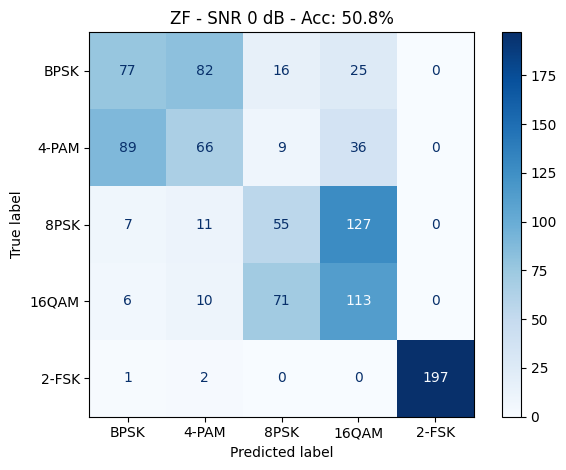

  SNR = 5 dB → Accuracy: 58.70%


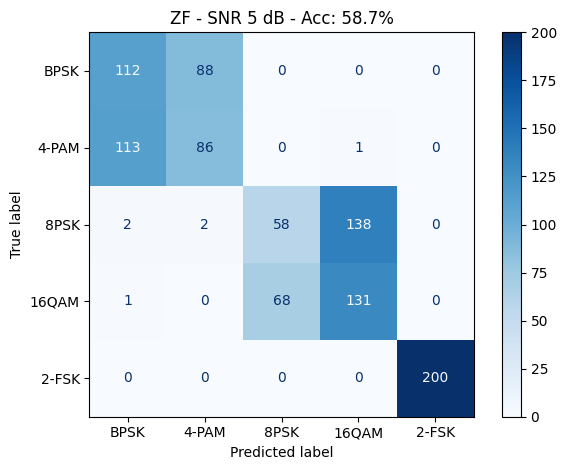

  SNR = 10 dB → Accuracy: 57.60%


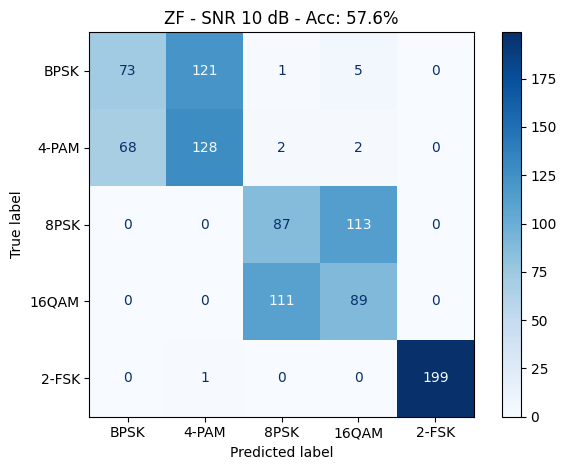

  SNR = 15 dB → Accuracy: 58.90%


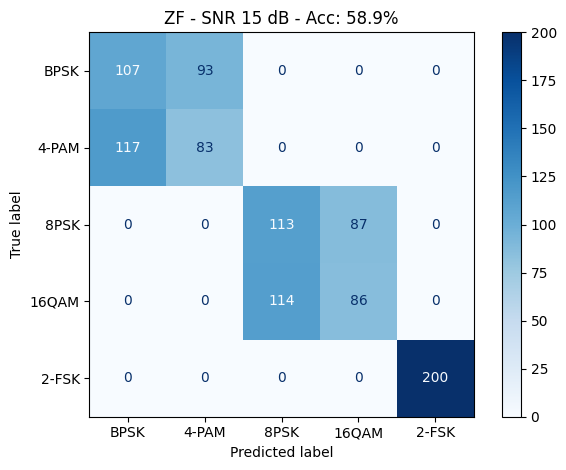

  SNR = 20 dB → Accuracy: 66.50%


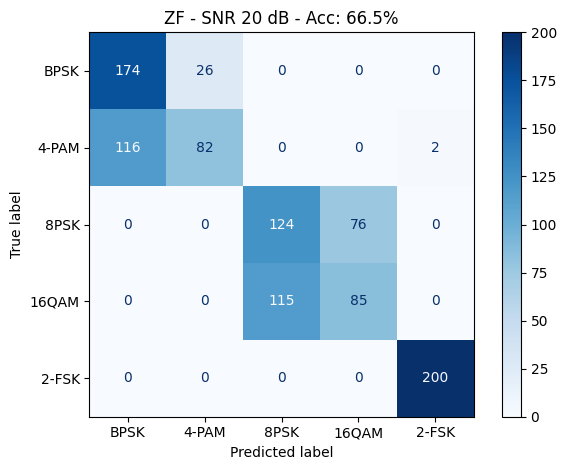

  SNR = 25 dB → Accuracy: 87.00%


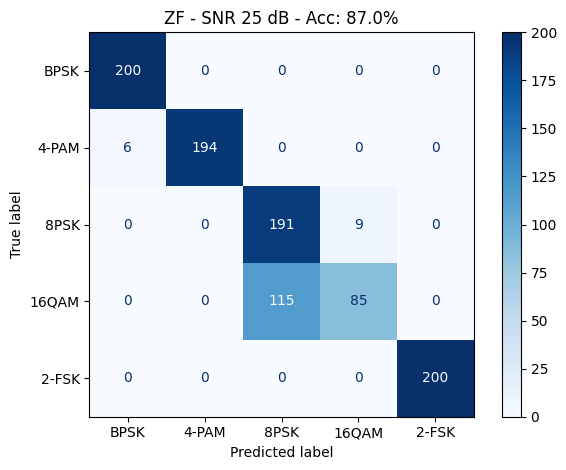


=== Dataset: MMSE ===
  SNR = -5 dB → Accuracy: 58.80%


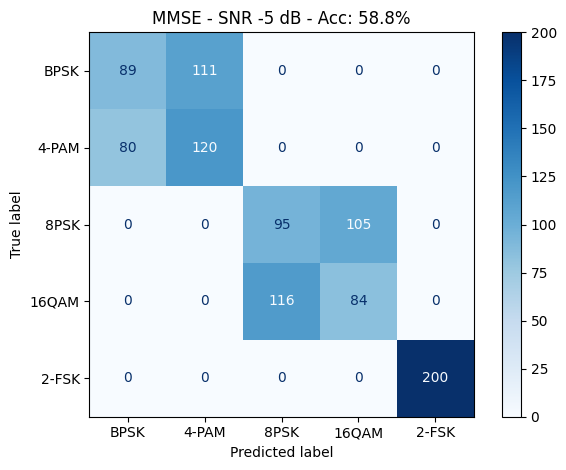

  SNR = 0 dB → Accuracy: 65.80%


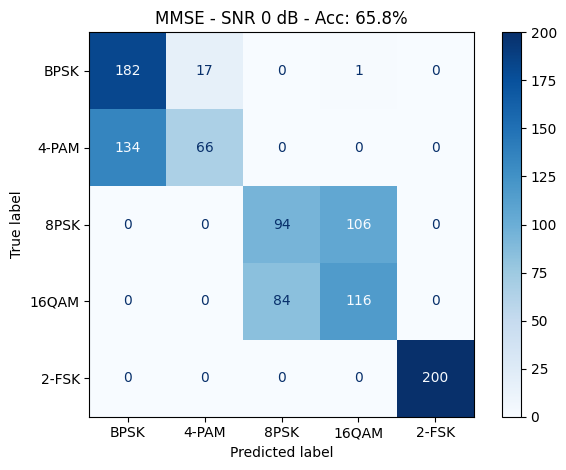

  SNR = 5 dB → Accuracy: 75.90%


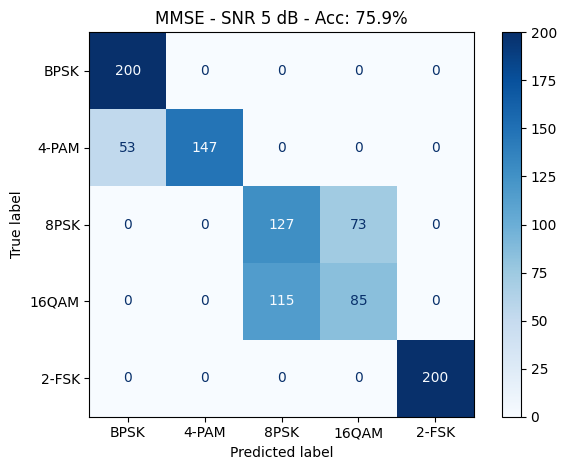

  SNR = 10 dB → Accuracy: 99.30%


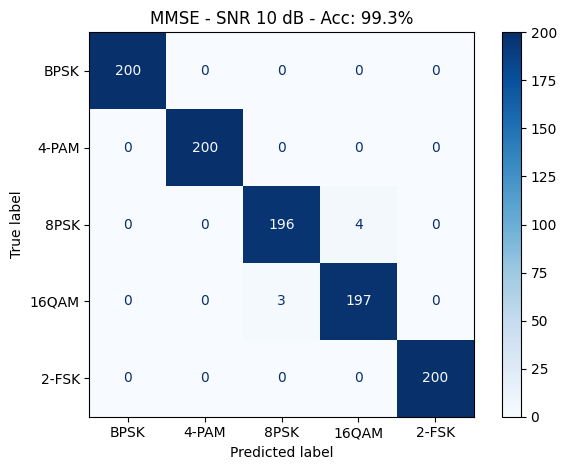

  SNR = 15 dB → Accuracy: 100.00%


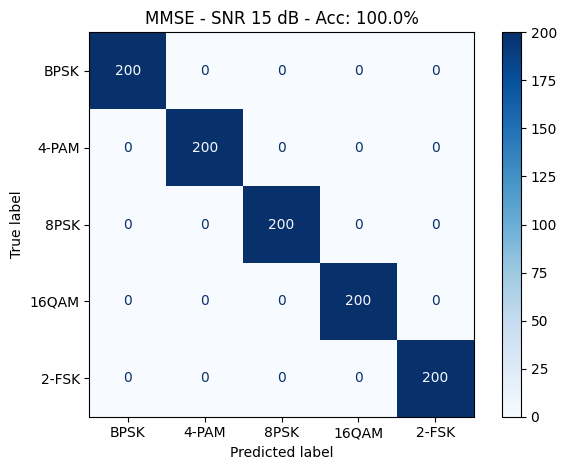

  SNR = 20 dB → Accuracy: 100.00%


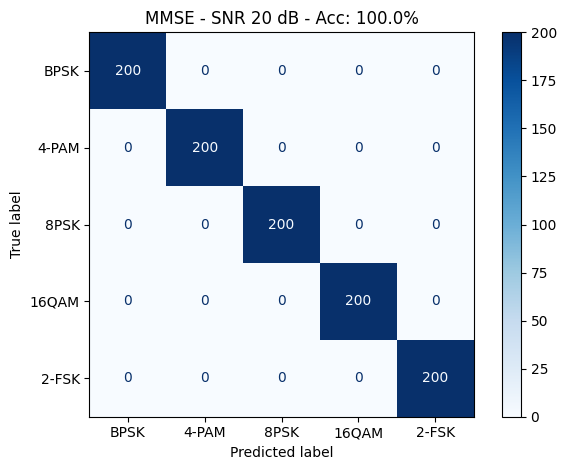

  SNR = 25 dB → Accuracy: 100.00%


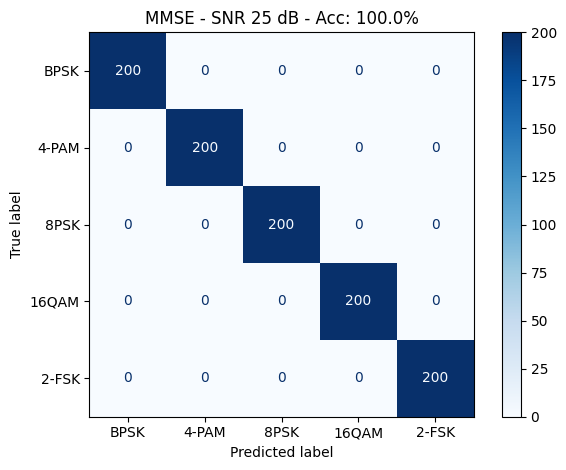

In [11]:
# =========================================================
# TRAINING AND EVALUATION
# =========================================================
results = {}

for name, path in DATASETS.items():
    print(f"\n=== Dataset: {name} ===")
    acc_global = []
    acc_per_mod = {snr: [] for snr in SNR_LIST}
    
    for snr in SNR_LIST:
        print(f"  SNR = {snr} dB", end="")
        
        # Load dataset
        X, y = load_data(path, snr)
        
        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )
        
        # Build and train CNN model
        model = build_cnn()
        model.fit(
            X_train, y_train,
            epochs=15,
            batch_size=64,
            validation_split=0.2,
            verbose=0
        )
        
        # Global evaluation
        _, acc = model.evaluate(X_test, y_test, verbose=0)
        acc_global.append(acc)
        print(f" → Accuracy: {acc*100:.2f}%")
        
        # Single prediction pass
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        
        # Per-modulation accuracy
        for label in range(NUM_CLASSES):
            mask = (y_test == label)
            if mask.sum() > 0:
                acc_mod = accuracy_score(y_test[mask], y_pred[mask])
            else:
                acc_mod = 0.0
            acc_per_mod[snr].append(acc_mod)
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=MOD_LABELS)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - SNR {snr} dB - Acc: {acc*100:.1f}%")
        plt.tight_layout()
        plt.show()
    
    results[name] = {'global': acc_global, 'per_mod': acc_per_mod}

## 4. Results Visualization

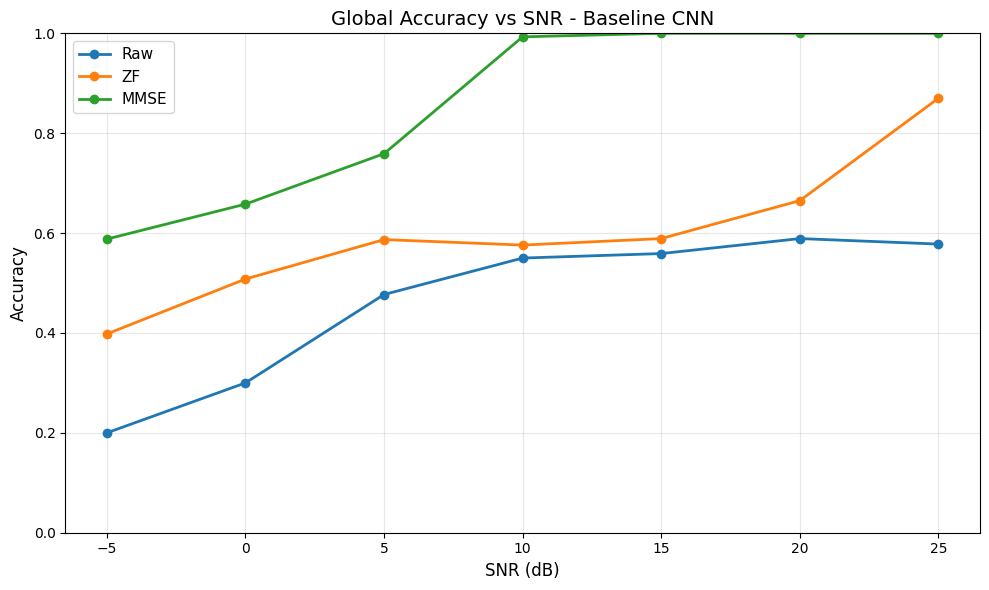

In [12]:
# =========================================================
# GLOBAL ACCURACY VS SNR
# =========================================================
plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(SNR_LIST, res['global'], marker='o', linewidth=2, label=name)
plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Global Accuracy vs SNR - Baseline CNN', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('baseline_global_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

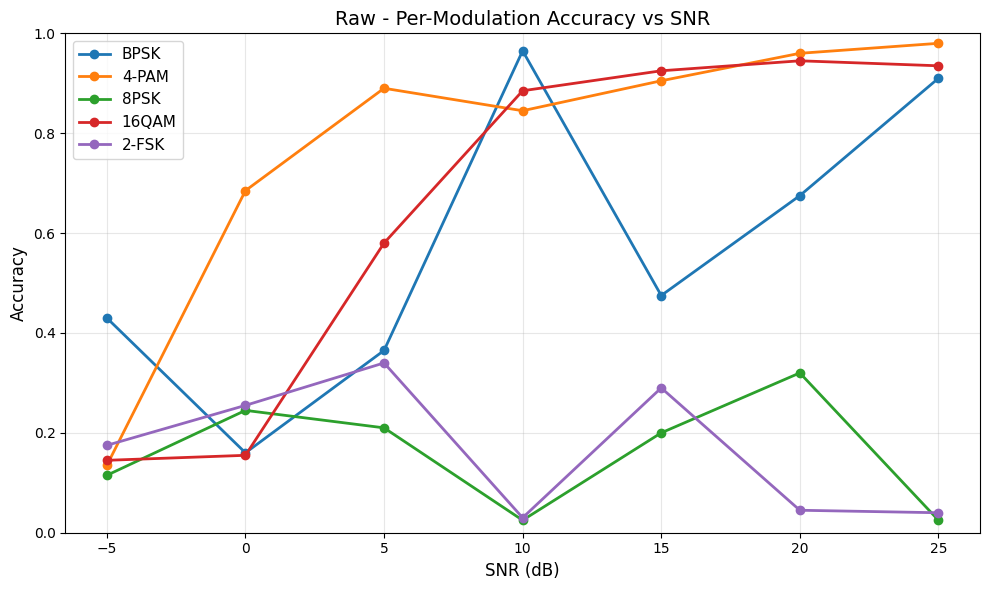

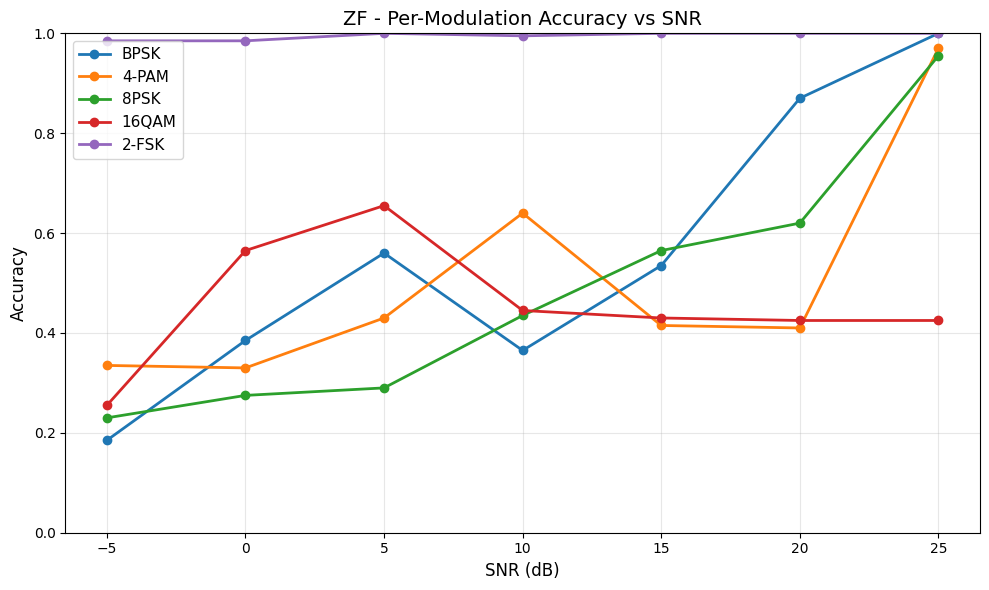

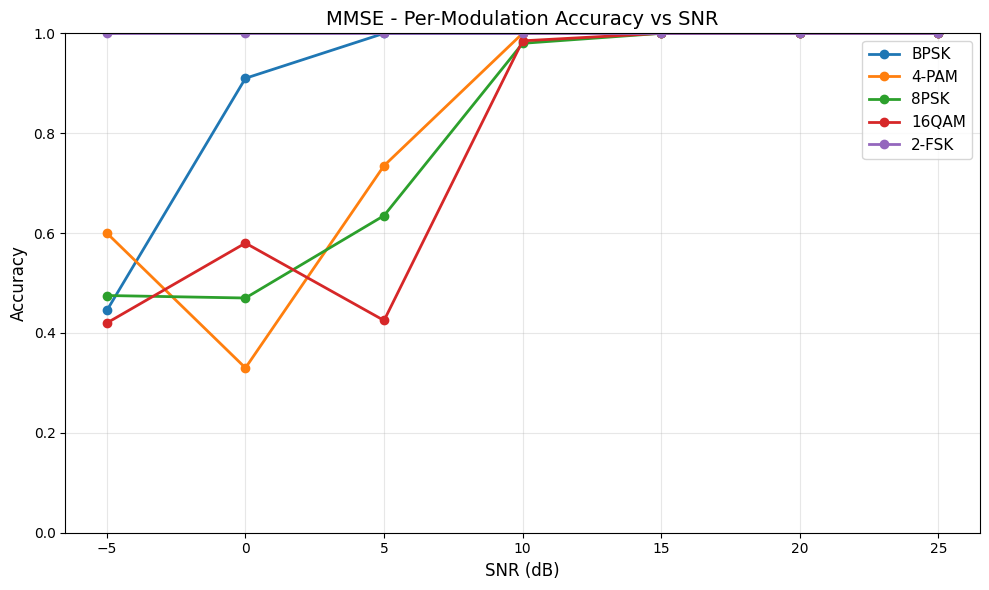

In [13]:
# =========================================================
# ACCURACY PER MODULATION VS SNR
# =========================================================
for name, res in results.items():
    plt.figure(figsize=(10, 6))
    for mod_idx, mod_name in enumerate(MOD_LABELS):
        accs = [res['per_mod'][snr][mod_idx] for snr in SNR_LIST]
        plt.plot(SNR_LIST, accs, marker='o', linewidth=2, label=mod_name)
    plt.xlabel('SNR (dB)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'{name} - Per-Modulation Accuracy vs SNR', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(f'baseline_{name}_per_modulation.png', dpi=300, bbox_inches='tight')
    plt.show()

## 6. Save Results for Later Analysis

In [14]:
import pickle

# Save results
with open('baseline_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Results saved to baseline_results.pkl")

Results saved to baseline_results.pkl


---

## Next Steps

After completing this baseline implementation:

1. Analyze confusion matrices to identify problematic modulation pairs
2. Investigate why certain modulations perform poorly at low SNR
3. Compare equalization strategies quantitatively
4. Move to `02_advanced_architectures.ipynb` to explore improved models

**Students:** Lyes HADJAR, Moulay Mohamed BOUABDELLI